## 1. Importación de Librerías

In [25]:
# Librerías estándar de análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

# Estilo de gráficas
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")
print("Librerías cargadas")

Librerías cargadas


## 2. Carga y Exploración Inicial de Datos (EDA)

In [26]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('Mall_Customers.xls')

print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
print("\n Primeras 5 filas:")
df.head()

Saving Mall_Customers.xls to Mall_Customers (3).xls
Dimensiones del dataset: 200 filas × 5 columnas

 Primeras 5 filas:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [27]:
# Información general del dataset
print("Tipos de datos y valores nulos:")
df.info()

Tipos de datos y valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [28]:
# Estadísticas descriptivas
print("Estadísticas descriptivas:")
df.describe().round(2)

Estadísticas descriptivas:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


In [29]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\n No hay valores nulos — el dataset está limpio")

# Distribución de género
print(f"\n Distribución de Género:")
print(df['Gender'].value_counts())
print(f"   → {df['Gender'].value_counts(normalize=True).mul(100).round(1).to_string()}")

Valores nulos por columna:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

 No hay valores nulos — el dataset está limpio

 Distribución de Género:
Gender
Female    112
Male       88
Name: count, dtype: int64
   → Gender
Female    56.0
Male      44.0


### 2.1 Visualización Exploratoria

Antes de aplicar algoritmos, es fundamental entender la distribución de las variables y detectar posibles patrones.

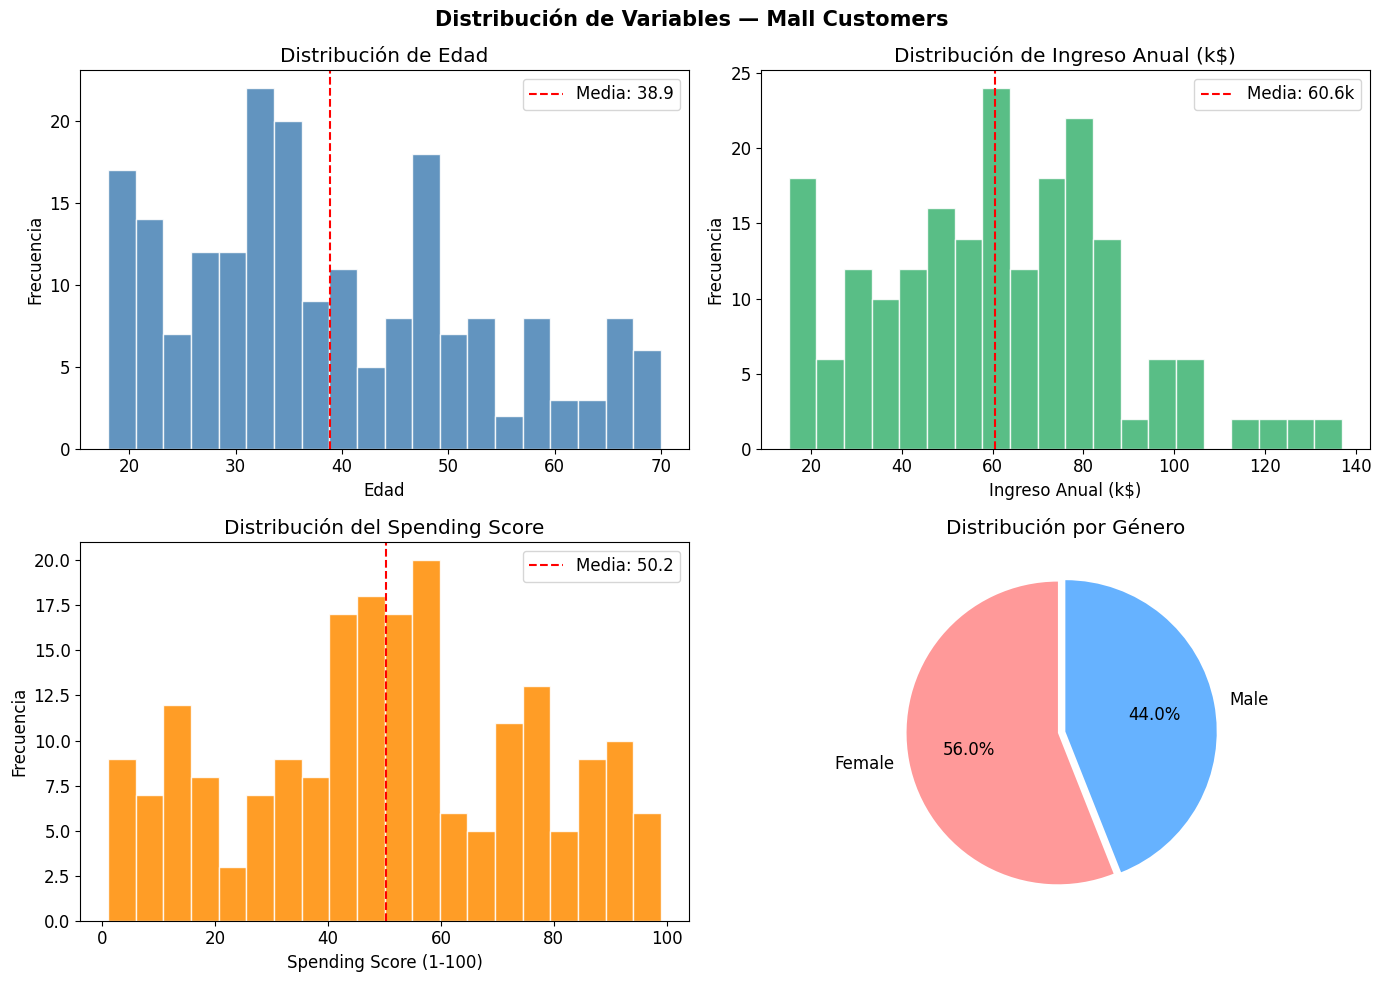

Gráfica guardada como 'eda_distribuciones.png'


In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables — Mall Customers', fontsize=15, fontweight='bold')

# Edad
axes[0,0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Distribución de Edad')
axes[0,0].set_xlabel('Edad')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Media: {df["Age"].mean():.1f}')
axes[0,0].legend()

# Ingreso anual
axes[0,1].hist(df['Annual Income (k$)'], bins=20, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0,1].set_title('Distribución de Ingreso Anual (k$)')
axes[0,1].set_xlabel('Ingreso Anual (k$)')
axes[0,1].set_ylabel('Frecuencia')
axes[0,1].axvline(df['Annual Income (k$)'].mean(), color='red', linestyle='--',
                  label=f'Media: {df["Annual Income (k$)"].mean():.1f}k')
axes[0,1].legend()

# score
axes[1,0].hist(df['Spending Score (1-100)'], bins=20, color='darkorange', edgecolor='white', alpha=0.85)
axes[1,0].set_title('Distribución del Spending Score')
axes[1,0].set_xlabel('Spending Score (1-100)')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].axvline(df['Spending Score (1-100)'].mean(), color='red', linestyle='--',
                  label=f'Media: {df["Spending Score (1-100)"].mean():.1f}')
axes[1,0].legend()

# Género
gender_counts = df['Gender'].value_counts()
axes[1,1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
              colors=['#FF9999','#66B2FF'], startangle=90, explode=(0.05, 0))
axes[1,1].set_title('Distribución por Género')

plt.tight_layout()
plt.savefig('eda_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'eda_distribuciones.png'")

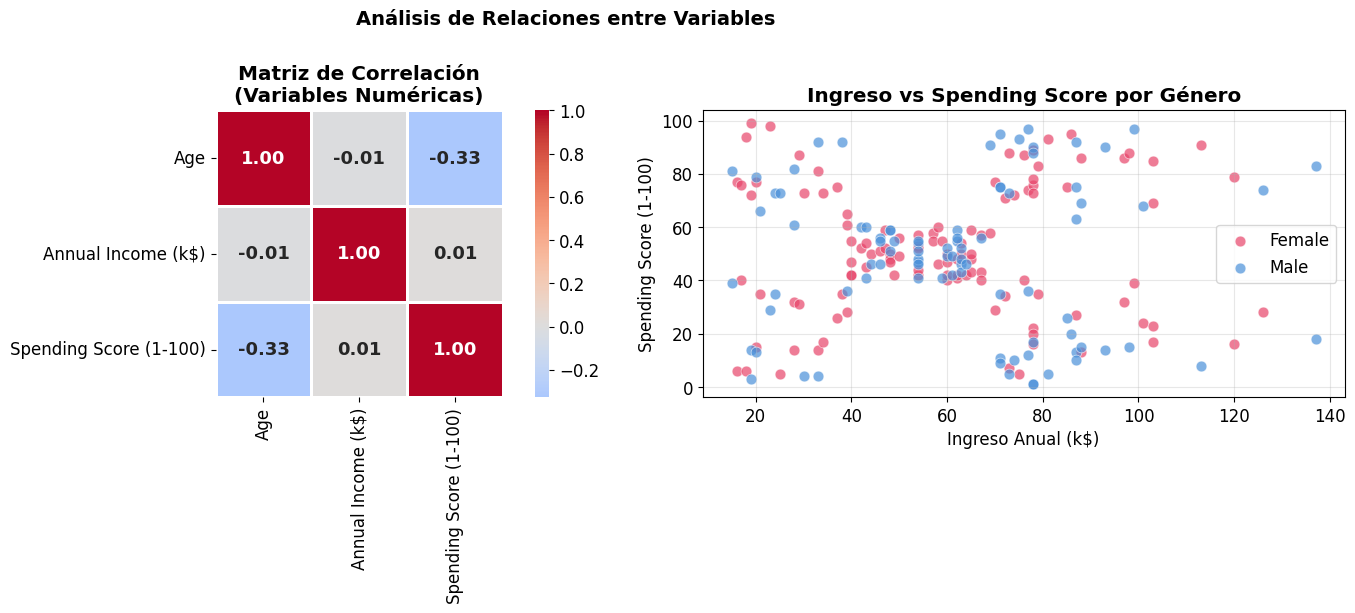

Gráfica guardada como 'eda_correlacion.png'


In [31]:
# Matriz de correlación
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap correlación
cols_num = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
corr = df[cols_num].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0], square=True, linewidths=1,
            annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title('Matriz de Correlación\n(Variables Numéricas)', fontweight='bold')

# Scatter Ingreso vs Spending Score por género
colors = {'Male': '#4A90D9', 'Female': '#E8456A'}
for gender, grp in df.groupby('Gender'):
    axes[1].scatter(grp['Annual Income (k$)'], grp['Spending Score (1-100)'],
                    c=colors[gender], label=gender, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
axes[1].set_xlabel('Ingreso Anual (k$)', fontsize=12)
axes[1].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[1].set_title('Ingreso vs Spending Score por Género', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Análisis de Relaciones entre Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'eda_correlacion.png'")

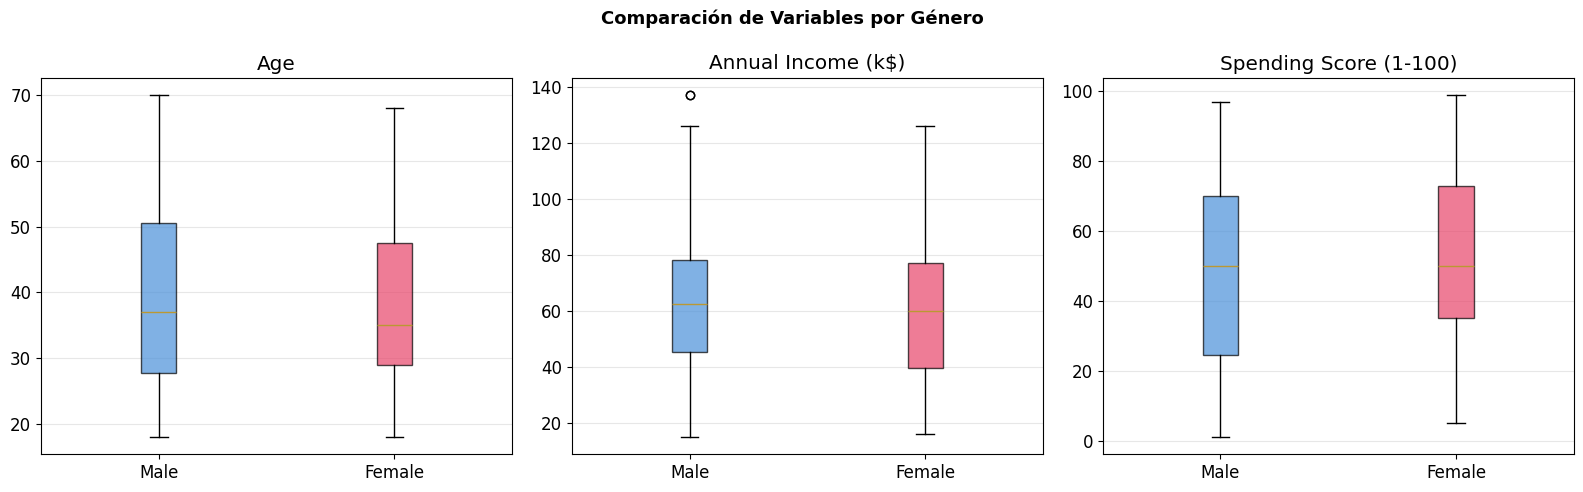

In [32]:
# Boxplots por género
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparación de Variables por Género', fontsize=13, fontweight='bold')

vars_plot = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors_box = ['#4A90D9', '#E8456A']

for i, var in enumerate(vars_plot):
    data_m = df[df['Gender']=='Male'][var]
    data_f = df[df['Gender']=='Female'][var]
    bp = axes[i].boxplot([data_m, data_f], labels=['Male', 'Female'],
                         patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(var)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocesamiento de Datos

Para los algoritmos de clustering (especialmente K-Means y DBSCAN que son sensibles a la escala),
es obligatorio estandarizar las variables numéricas. También codificaremos el género para poder incluirlo.

In [33]:
# Codificar género (Male=0, Female=1)
le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Gender'])

# Seleccionar features para clustering
# Usaremos Ingreso y Spending Score (las más relevantes para segmentación de mercado)
X_2d = df[['Annual Income (k$)', 'Spending Score (1-100)']].copy()

# Dataset completo (incluyendo edad y género)
X_full = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_encoded']].copy()

# Estandarizar
scaler = StandardScaler()
X_2d_scaled = scaler.fit_transform(X_2d)
X_full_scaled = scaler.fit_transform(X_full)

print(" Preprocesamiento completado")
print(f"\n Features 2D (Ingreso + Spending): {X_2d_scaled.shape}")
print(f" Features completas: {X_full_scaled.shape}")
print(f"\nEstadísticas después de estandarizar (X_2d):")
print(f"  Media: {X_2d_scaled.mean(axis=0).round(4)}")
print(f"  Std:   {X_2d_scaled.std(axis=0).round(4)}")

 Preprocesamiento completado

 Features 2D (Ingreso + Spending): (200, 2)
 Features completas: (200, 4)

Estadísticas después de estandarizar (X_2d):
  Media: [-0. -0.]
  Std:   [1. 1.]


## 4. Algoritmo 1: K-Means Clustering

### ¿Por qué K-Means?
K-Means es el algoritmo de clustering más utilizado en la industria. Es eficiente, interpretable y funciona muy bien cuando los clusters tienen forma globular.

**Ventajas para este caso:**
- Fácil de interpretar los centroides como "cliente tipo"
- Escala bien a datasets medianos
- Buenas métricas de evaluación disponibles

**Limitaciones:**
- Requiere definir K a priori
- Asume clusters esféricos y de tamaño similar
- Sensible a outliers

### 4.1 Método del Codo (Elbow Method) para determinar K

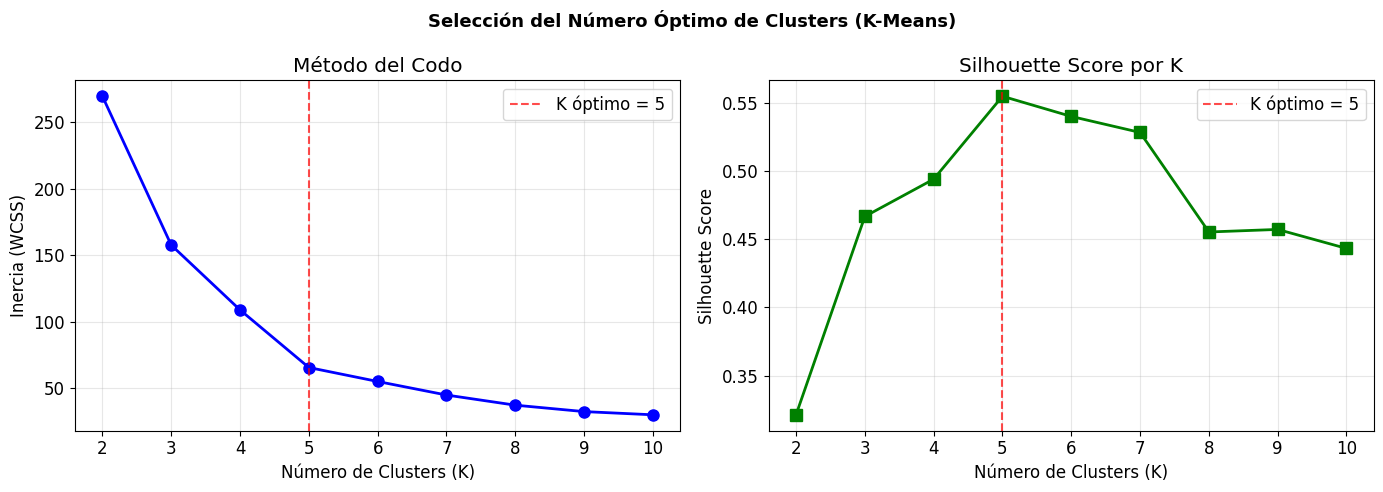

Resultados por K:
  K=2: Inercia=269.7, Silhouette=0.321
  K=3: Inercia=157.7, Silhouette=0.467
  K=4: Inercia=108.9, Silhouette=0.494
  K=5: Inercia=65.6, Silhouette=0.555
  K=6: Inercia=55.1, Silhouette=0.540
  K=7: Inercia=44.9, Silhouette=0.528
  K=8: Inercia=37.2, Silhouette=0.455
  K=9: Inercia=32.4, Silhouette=0.457
  K=10: Inercia=30.0, Silhouette=0.443


In [34]:
# Método del codo para encontrar K óptimo
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_2d_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_2d_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Selección del Número Óptimo de Clusters (K-Means)', fontsize=13, fontweight='bold')

# Elbow
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(5, color='red', linestyle='--', alpha=0.7, label='K óptimo = 5')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(K_range, silhouettes, 'gs-', linewidth=2, markersize=8)
axes[1].axvline(5, color='red', linestyle='--', alpha=0.7, label='K óptimo = 5')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

print("Resultados por K:")
for k, ine, sil in zip(K_range, inertias, silhouettes):
    print(f"  K={k}: Inercia={ine:.1f}, Silhouette={sil:.3f}")